# 설명변수 EDA

**데이터**: `data/final/eda_master_v2_by_gu_year.csv` (25구 × 4년, 100행)

**변수 구성**

| 구분 | 변수 | 비고 |
|------|------|------|
| 종속변수 | waste_per_capita_kg_day, waste_total, food_waste_total, recycle_rate | 2020~2023 |
| 패널 설명변수 | total_pop, households, elderly_ratio, living_pop_daily_avg, day_night_ratio, biz_total, food_accom_biz, illegal_dumping_count | 2020~2023, n=100 |
| 2023 한정 변수 | parcel_arrival_total, arrival_per_hh | 2023만 존재, n=25 |

> `waste_per_capita_kg_day` = waste_total(톤) × 1000 ÷ total_pop ÷ 365  →  **1인 1일 쓰레기 배출량 (kg)**

> **결측 처리 전략**: parcel 2개 변수는 패널 분석 제외 → 섹션 6에서 2023 단면(n=25)으로 별도 분석

## 0. 환경 설정

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

print('설정 완료')

설정 완료


In [2]:
df = pd.read_csv('../../../data/final/eda_master_v2_by_gu_year.csv',
                 encoding='utf-8-sig')

# 파생변수: 1인 1일 쓰레기 배출량 (kg)
df['waste_per_capita_kg_day'] = (
    df['waste_total'] * 1000 / df['total_pop'] / 365
).round(4)

# 파생변수: 인구 1만명당 무단투기 단속건수
df['illegal_dumping_per_10k'] = (
    df['illegal_dumping_count'] / df['total_pop'] * 10000
).round(2)

# 파생변수: 인구 1만명당 사업체 수
df['biz_per_10k_pop'] = (
    df['biz_total'] / df['total_pop'] * 10000
).round(2)

# 파생변수: 인구 1만명당 음식숙박업 수
df['food_accom_biz_per_10k_pop'] = (
    df['food_accom_biz'] / df['total_pop'] * 10000
).round(2)

df23 = df[df['year'] == 2023].reset_index(drop=True)  # parcel 분석용

print(f'전체 shape : {df.shape}')
print(f'2023 단면  : {df23.shape}')
print()
print(df[['year','gu','biz_per_10k_pop','food_accom_biz_per_10k_pop','waste_per_capita_kg_day']].head(5).to_string(index=False))

전체 shape : (100, 20)
2023 단면  : (25, 20)

 year  gu  biz_per_10k_pop  food_accom_biz_per_10k_pop  waste_per_capita_kg_day
 2020 강남구          2114.75                       70.14                   1.2807
 2020 강동구           883.15                      105.54                   0.7953
 2020 강북구           857.31                       96.09                   0.7825
 2020 강서구          1003.38                      144.91                   0.9015
 2020 관악구           757.92                       79.44                   0.7899


In [3]:
# 패널 설명변수 (2020~2023, 결측 없음)
EXPL_PANEL = [
    'total_pop', 'households', 'elderly_ratio',
    'living_pop_daily_avg', 'day_night_ratio',
    'biz_total', 'food_accom_biz',
    'illegal_dumping_per_10k'
]

# 2023 한정 설명변수
EXPL_2023 = ['parcel_arrival_total', 'arrival_per_hh']

TARGET_COLS = ['waste_per_capita_kg_day', 'waste_total', 'food_waste_total', 'recycle_rate']

COL_KR = {
    'total_pop':                   '등록인구',
    'households':                  '세대수',
    'elderly_ratio':               '고령인구 비율 (%)',
    'living_pop_daily_avg':        '생활인구 일평균',
    'day_night_ratio':             '주야간 인구비',
    'biz_total':                   '사업체 수',
    'food_accom_biz':              '음식숙박업 수',
    'illegal_dumping_per_10k':     '무단투기 단속건수 (만명당)',
    'biz_per_10k_pop':             '사업체 수 (만명당)',
    'food_accom_biz_per_10k_pop':  '음식숙박업 수 (만명당)',
    'parcel_arrival_total':        '택배 착지량',
    'arrival_per_hh':              '세대당 택배량',
    'waste_per_capita_kg_day':     '1인 1일 쓰레기 (kg)',
    'waste_total':                 '쓰레기 총량 (톤)',
    'food_waste_total':            '음식물 쓰레기 (톤)',
    'recycle_rate':                '재활용률 (%)',
}

year_colors = {2020: '#4C72B0', 2021: '#55A868', 2022: '#C44E52', 2023: '#DD8452'}
str_pal     = {str(k): v for k, v in year_colors.items()}

print('패널 설명변수:', EXPL_PANEL)
print('2023 한정   :', EXPL_2023)

패널 설명변수: ['total_pop', 'households', 'elderly_ratio', 'living_pop_daily_avg', 'day_night_ratio', 'biz_total', 'food_accom_biz', 'illegal_dumping_per_10k']
2023 한정   : ['parcel_arrival_total', 'arrival_per_hh']


---
## 1. 기술통계

In [4]:
print('=== 결측치 현황 ===')
print(df.isnull().sum().to_string())
print()
print('=== 기술통계 (패널 설명변수) ===')
df[EXPL_PANEL].describe().round(2)

=== 결측치 현황 ===
year                           0
gu                             0
waste_total                    0
waste_per_capita               0
food_waste_total               0
recycle_rate                   0
total_pop                      0
households                     0
elderly_ratio                  0
parcel_arrival_total          75
arrival_per_hh                75
living_pop_daily_avg           0
day_night_ratio                0
biz_total                      0
food_accom_biz                 0
illegal_dumping_count          0
waste_per_capita_kg_day        0
illegal_dumping_per_10k        0
biz_per_10k_pop                0
food_accom_biz_per_10k_pop     0

=== 기술통계 (패널 설명변수) ===


,total_pop,households,elderly_ratio,living_pop_daily_avg,day_night_ratio,biz_total,food_accom_biz,illegal_dumping_per_10k
count,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
mean,389535.83,177596.74,17.15,9954234.05,1.06,47564.56,4516.02,165.13
std,124061.03,55331.01,1.96,3332884.78,0.22,19746.05,1894.78,232.42
min,130785.00,63139.00,13.80,5199378.44,0.86,25193.00,1642.00,6.18
25%,313384.00,143625.25,15.82,8145072.47,0.91,35049.50,3133.50,49.17
50%,396082.00,180812.00,16.97,9192426.27,0.98,41142.00,4200.50,93.52
75%,464645.75,202560.25,18.20,11408770.65,1.13,57260.00,5802.25,162.86
max,673926.00,285927.00,23.42,19543105.99,1.86,115054.00,9712.00,1347.13


---
## 2. 분포 분석 (히스토그램 + KDE, 패널 n=100)

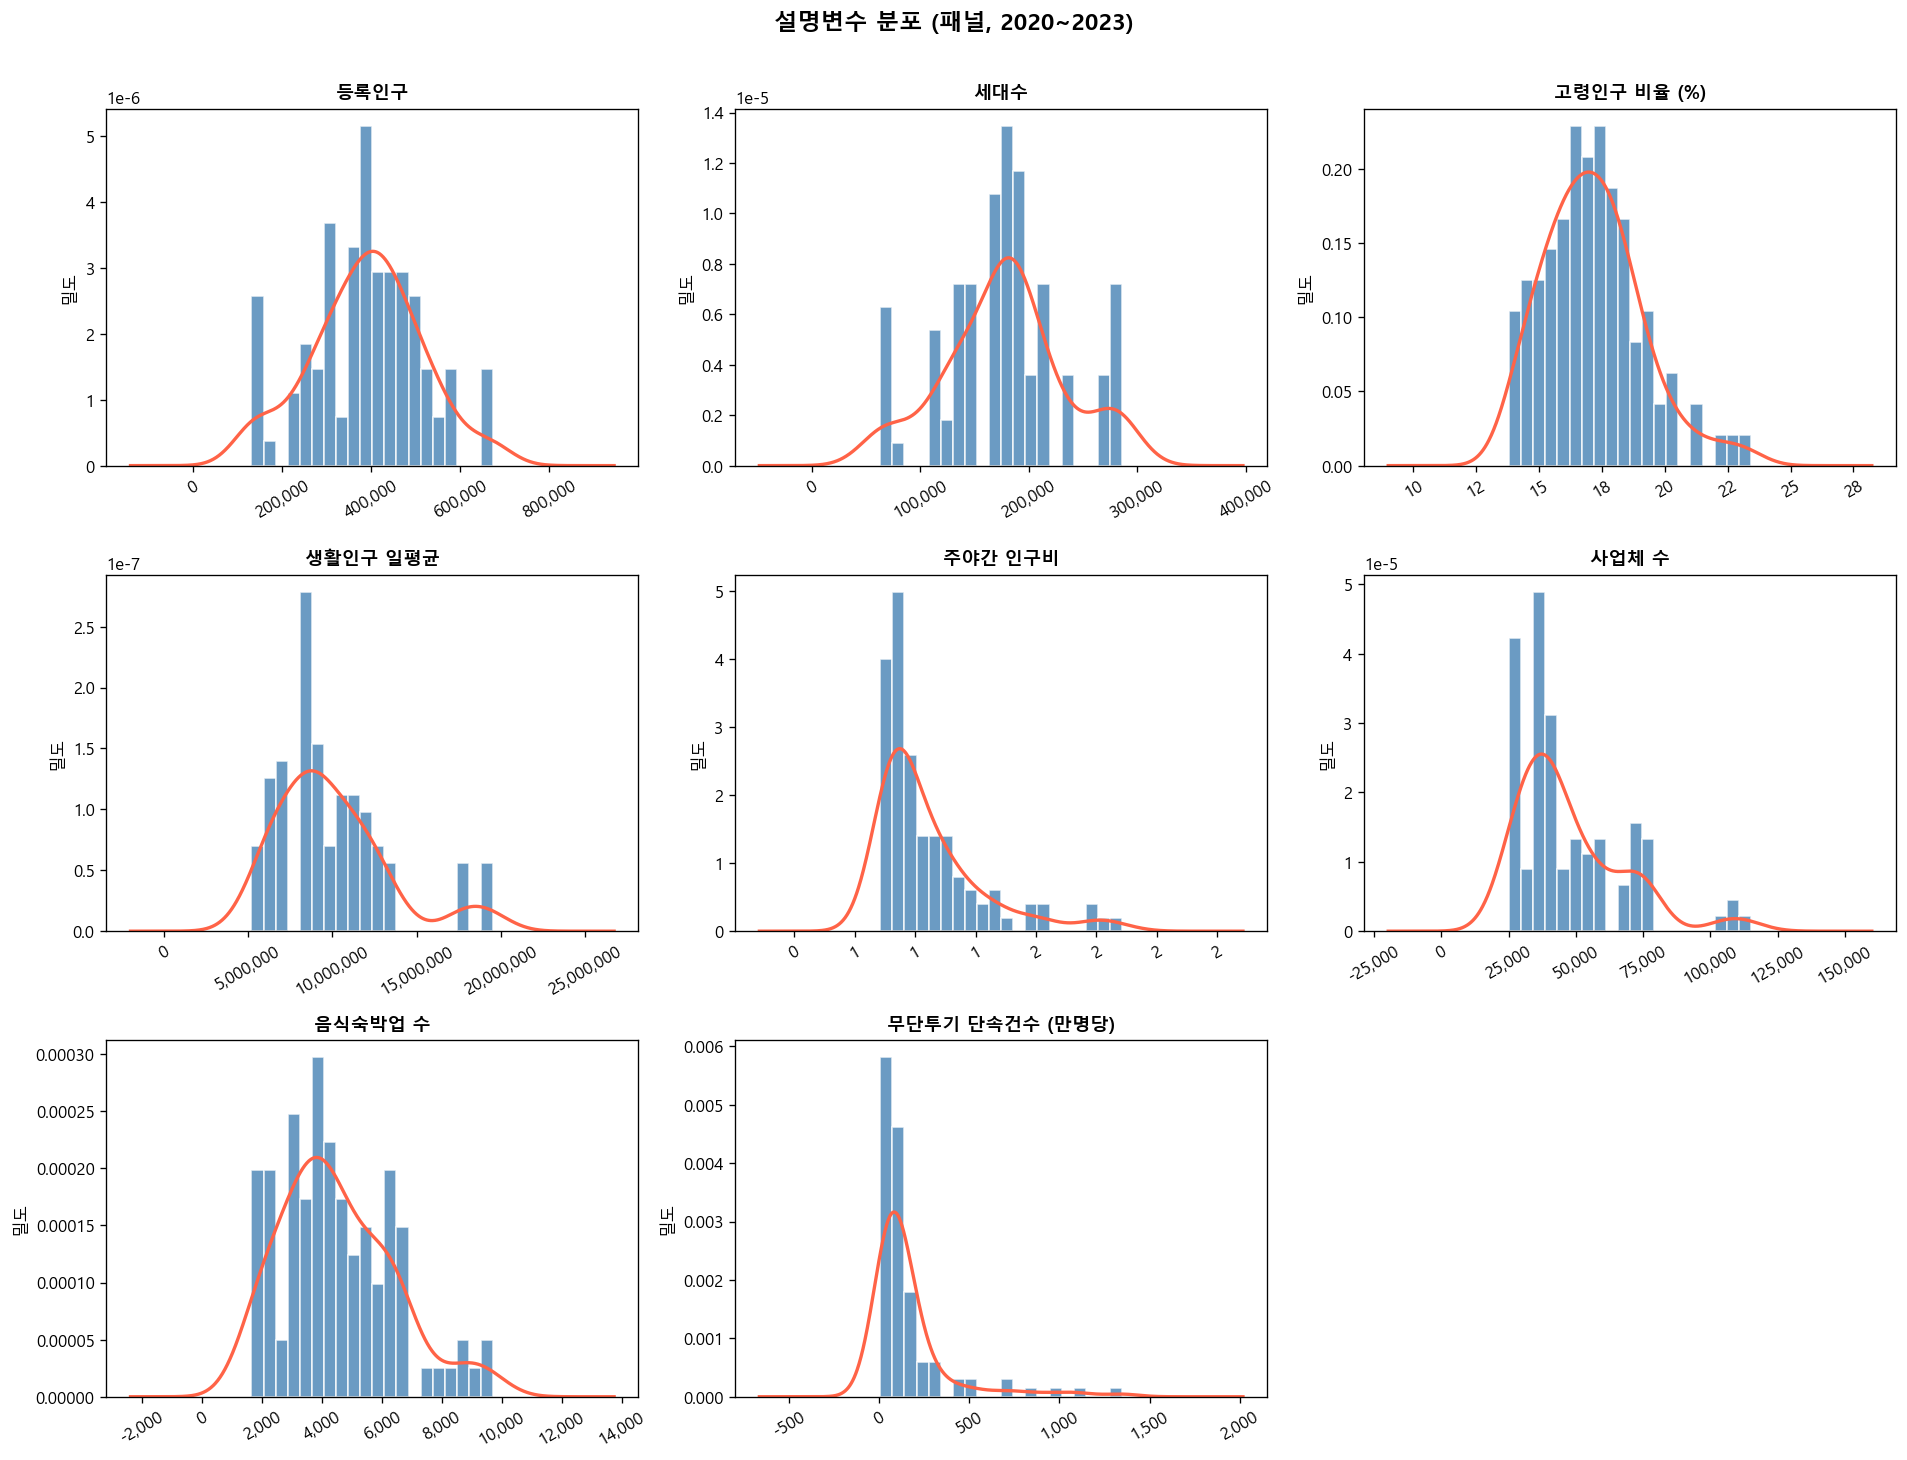

In [5]:
ncols = 3
nrows = (len(EXPL_PANEL) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(EXPL_PANEL):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=20, color='steelblue', edgecolor='white', alpha=0.8, density=True)
    data.plot.kde(ax=ax, color='tomato', linewidth=2)
    ax.set_title(COL_KR.get(col, col), fontsize=11, fontweight='bold')
    ax.set_ylabel('밀도')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.tick_params(axis='x', rotation=30)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('설명변수 분포 (패널, 2020~2023)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 3. 연도별 박스플롯

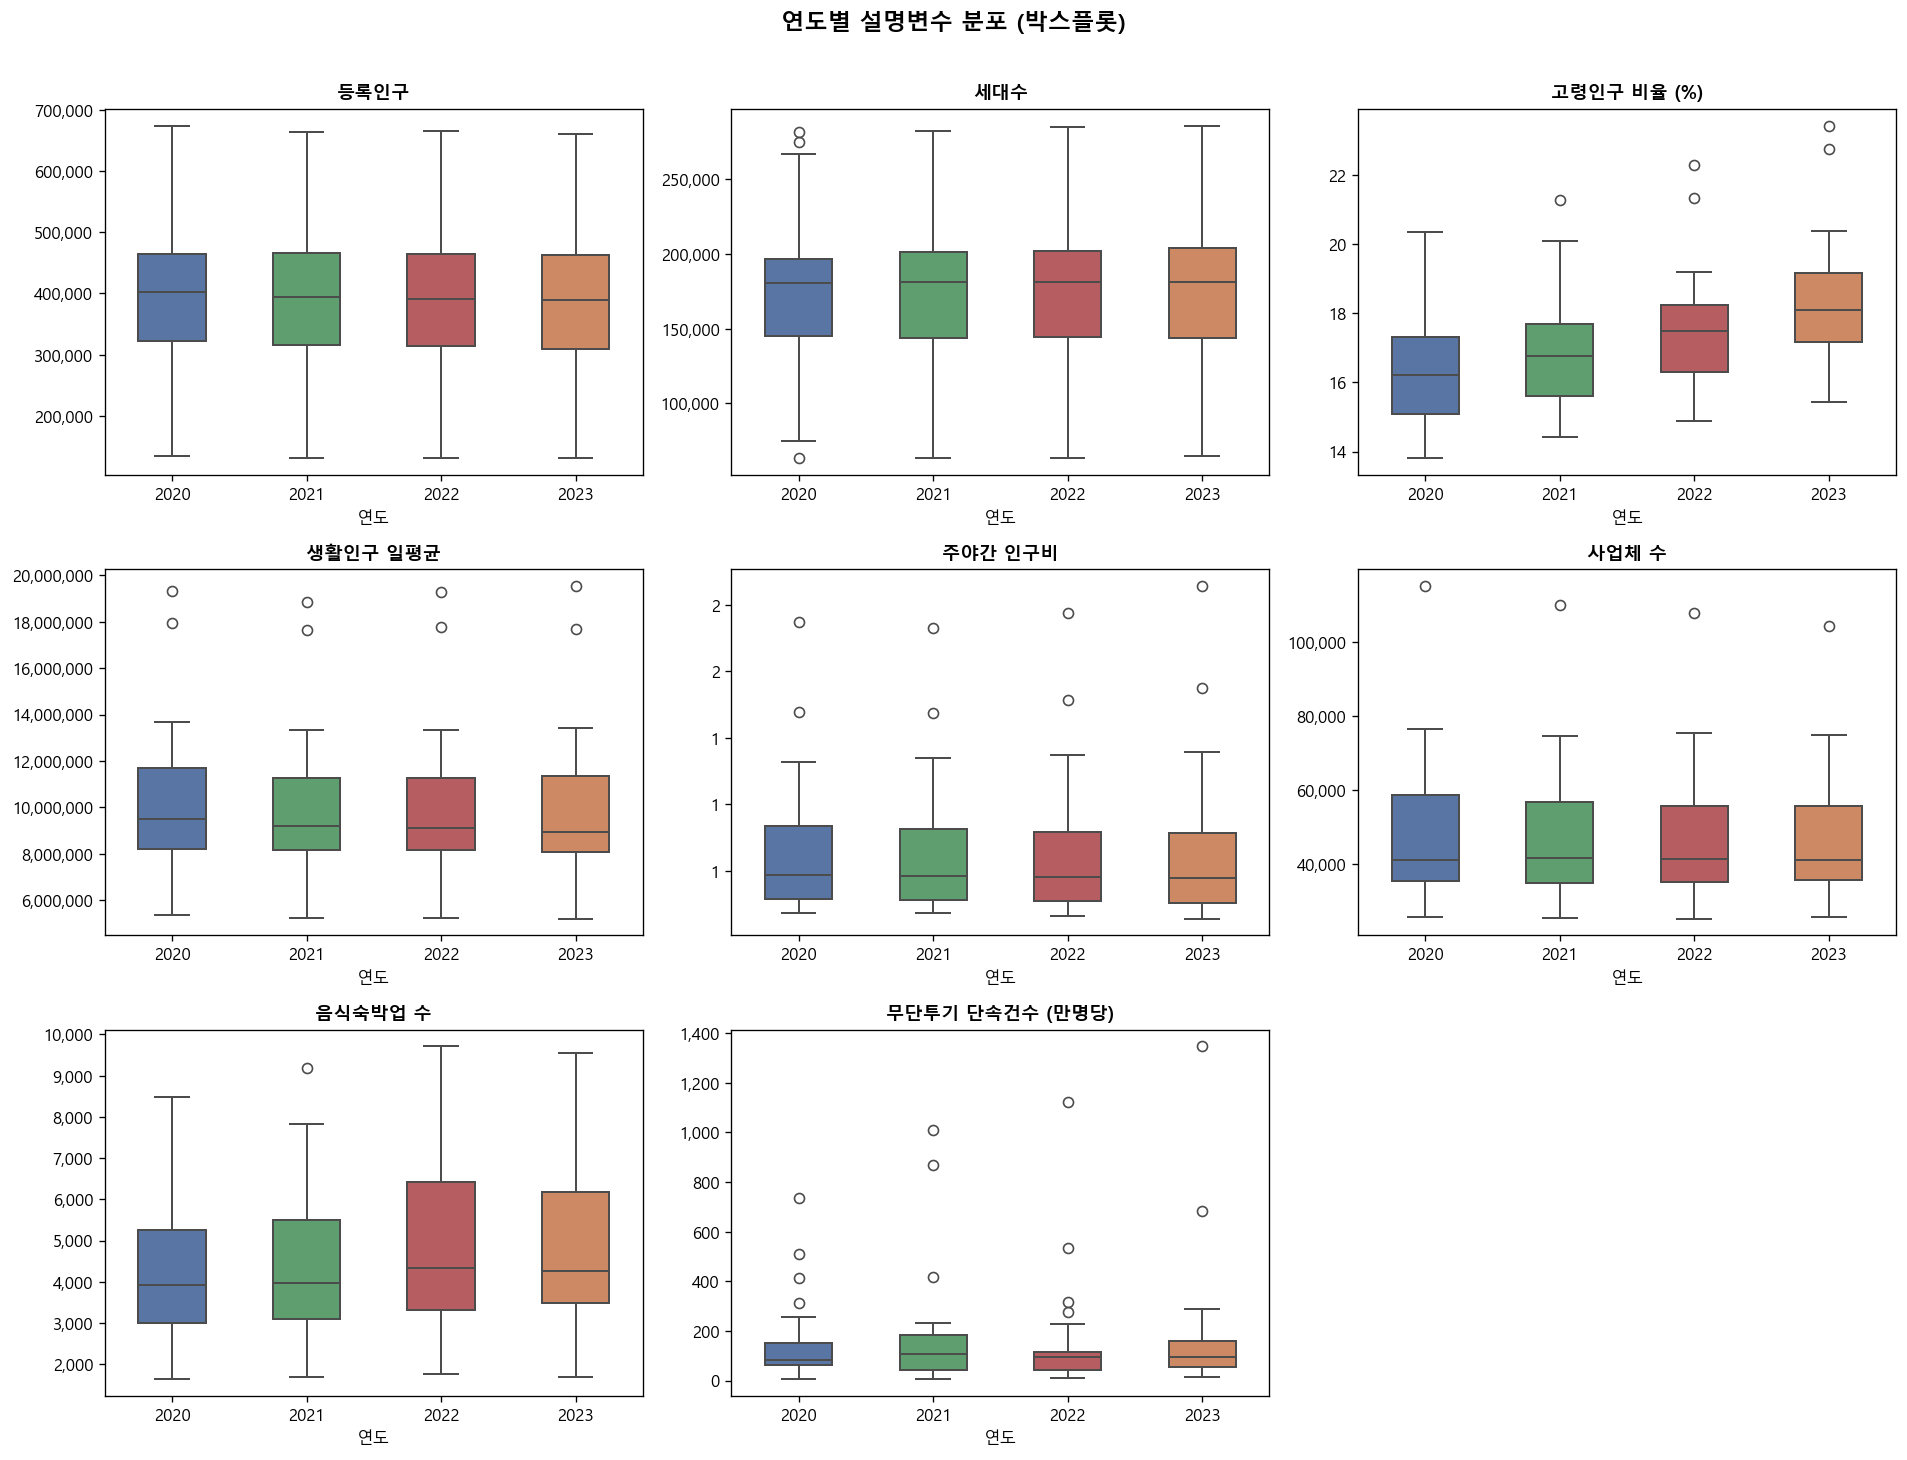

In [6]:
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(EXPL_PANEL):
    ax = axes[i]
    sns.boxplot(data=df, x='year', y=col, ax=ax,
                palette=str_pal, width=0.5, linewidth=1.2)
    ax.set_title(COL_KR.get(col, col), fontsize=11, fontweight='bold')
    ax.set_xlabel('연도')
    ax.set_ylabel('')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('연도별 설명변수 분포 (박스플롯)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 4. 상관계수 히트맵 (패널, n=100)

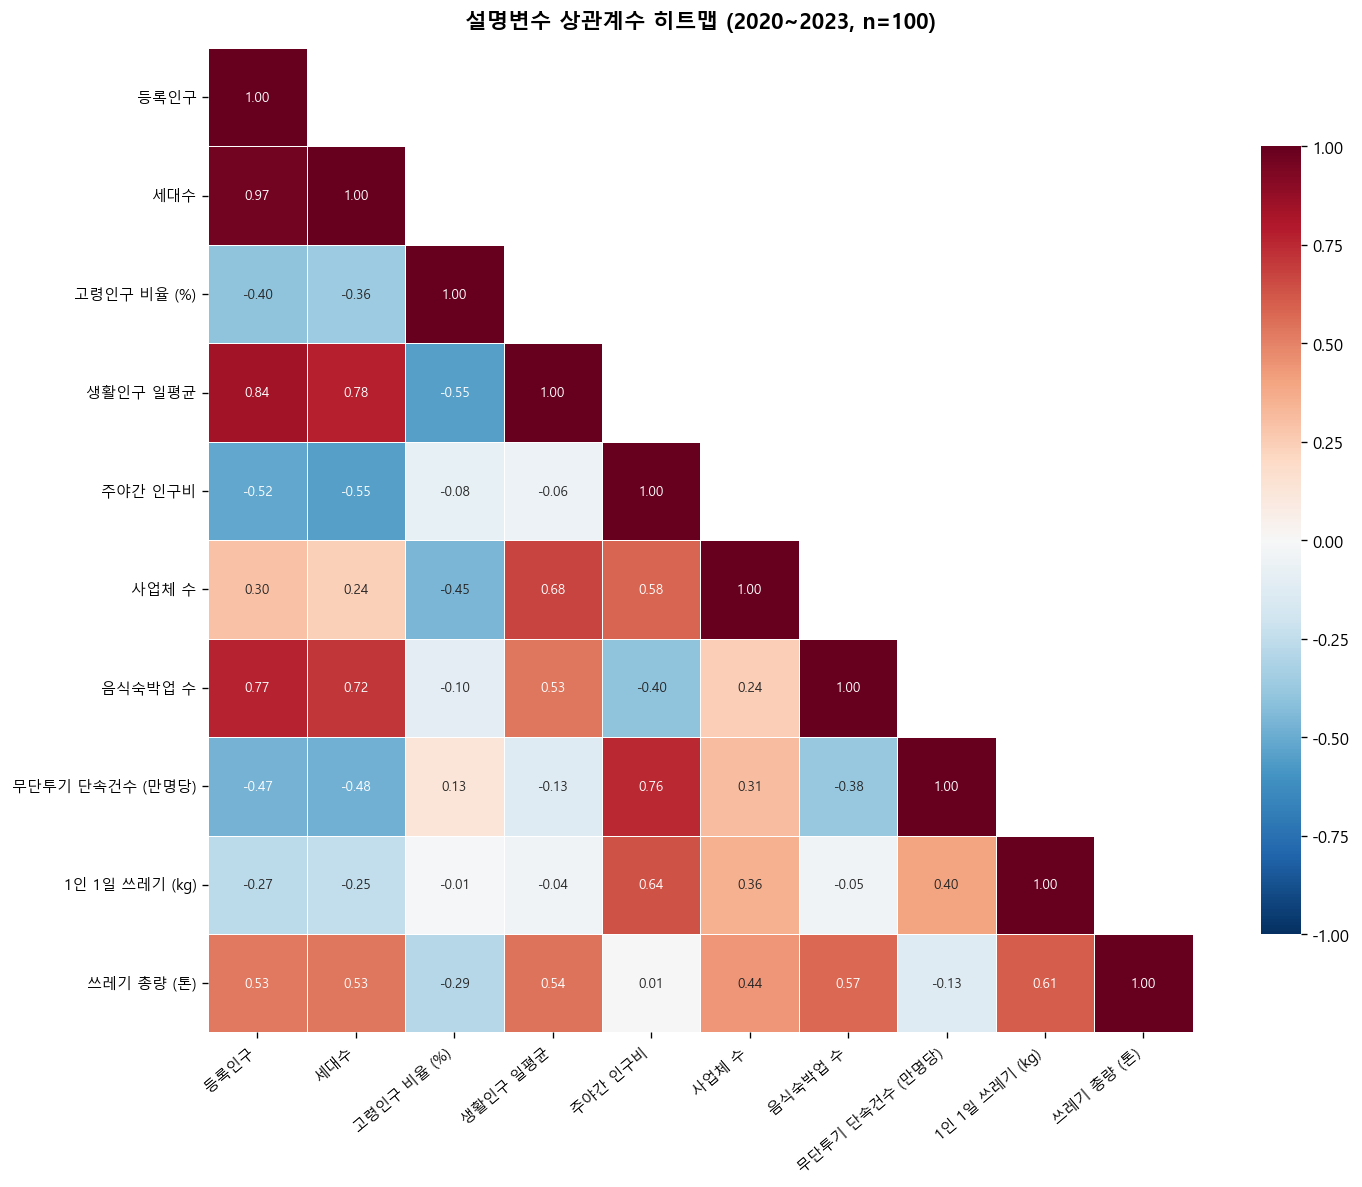

In [7]:
hm_cols = EXPL_PANEL + ['waste_per_capita_kg_day', 'waste_total']
corr    = df[hm_cols].corr()
labels  = [COL_KR.get(c, c) for c in hm_cols]

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(
    corr, mask=mask,
    annot=True, fmt='.2f', annot_kws={'size': 8},
    cmap='RdBu_r', vmin=-1, vmax=1, center=0,
    linewidths=0.4, linecolor='white',
    xticklabels=labels, yticklabels=labels,
    ax=ax, square=True, cbar_kws={'shrink': 0.8}
)
ax.set_title('설명변수 상관계수 히트맵 (2020~2023, n=100)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0,  fontsize=9)
plt.tight_layout()
plt.show()

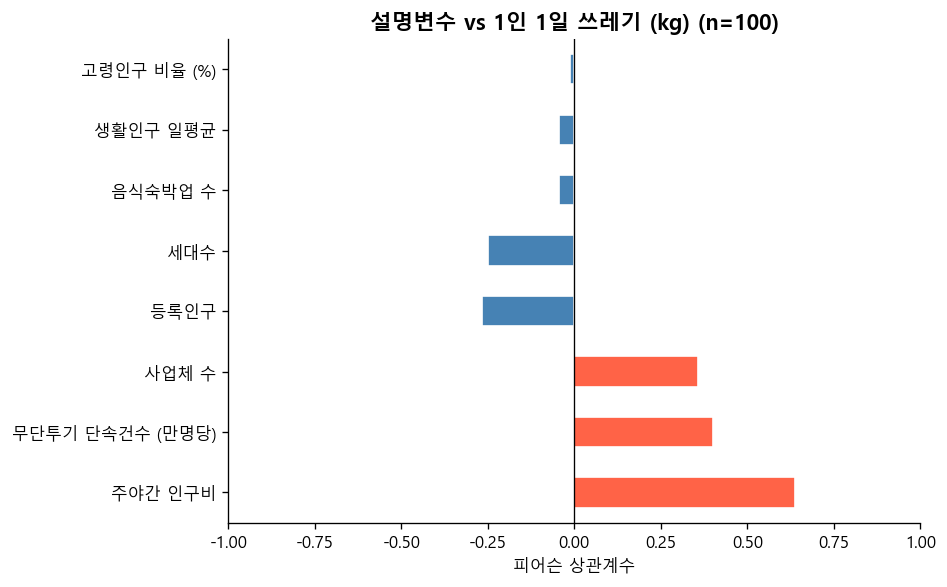

day_night_ratio            0.638
illegal_dumping_per_10k    0.400
biz_total                  0.356
total_pop                 -0.267
households                -0.248
food_accom_biz            -0.045
living_pop_daily_avg      -0.044
elderly_ratio             -0.013


In [8]:
target = 'waste_per_capita_kg_day'
corr_target = (df[EXPL_PANEL + [target]]
               .corr()[target].drop(target)
               .sort_values(key=abs, ascending=False))

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['tomato' if v > 0 else 'steelblue' for v in corr_target]
corr_target.plot.barh(ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlim(-1, 1)
ax.set_xlabel('피어슨 상관계수')
ax.set_title(f'설명변수 vs {COL_KR[target]} (n=100)', fontsize=13, fontweight='bold')
ax.set_yticklabels([COL_KR.get(c, c) for c in corr_target.index])
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

print(corr_target.round(3).to_string())

---
## 5. 설명변수 vs 종속변수 산점도 (패널, n=100)

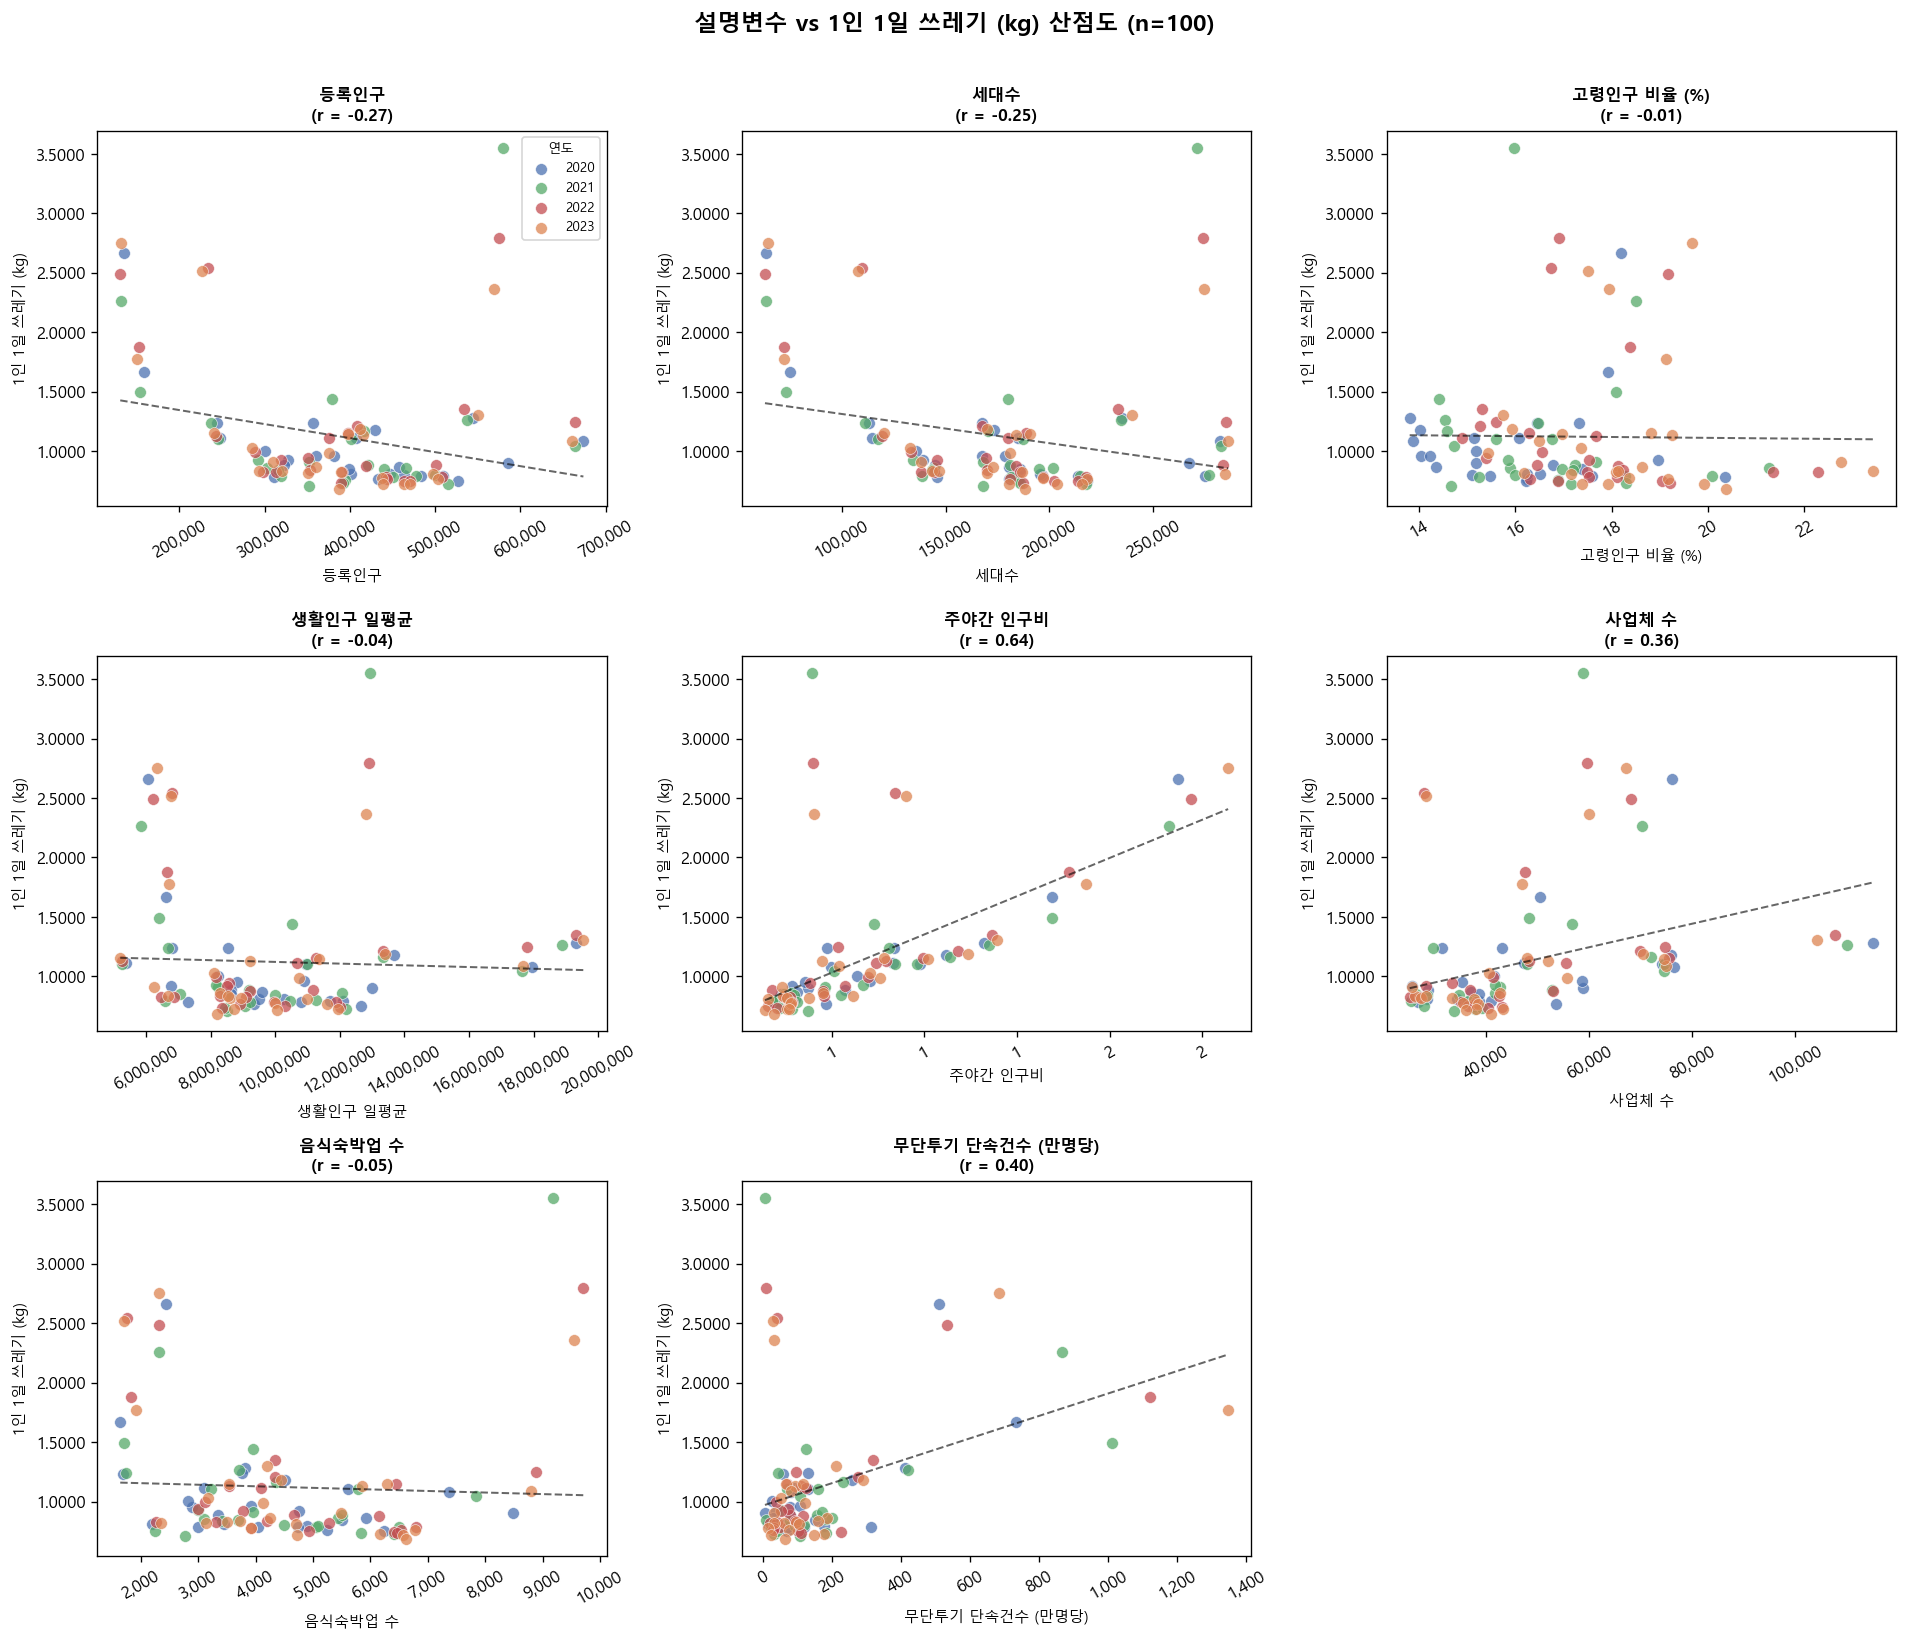

In [9]:
target       = 'waste_per_capita_kg_day'
target_label = COL_KR[target]
ncols = 3
nrows = (len(EXPL_PANEL) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4.5 * nrows))
axes = axes.flatten()

for i, col in enumerate(EXPL_PANEL):
    ax = axes[i]
    for yr, grp in df.groupby('year'):
        ax.scatter(grp[col], grp[target],
                   label=str(yr), color=year_colors[yr],
                   alpha=0.75, s=50, edgecolors='white', linewidths=0.4)
    valid = df[[col, target]].dropna()
    if len(valid) > 3:
        z = np.polyfit(valid[col], valid[target], 1)
        x_line = np.linspace(valid[col].min(), valid[col].max(), 100)
        ax.plot(x_line, np.poly1d(z)(x_line), 'k--', linewidth=1.2, alpha=0.6)
    r = df[[col, target]].corr().iloc[0, 1]
    ax.set_title(f'{COL_KR.get(col, col)}\n(r = {r:.2f})', fontsize=10, fontweight='bold')
    ax.set_xlabel(COL_KR.get(col, col), fontsize=9)
    ax.set_ylabel(target_label, fontsize=9)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.4f}'))
    ax.tick_params(axis='x', rotation=30)
    if i == 0:
        ax.legend(title='연도', fontsize=8, title_fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f'설명변수 vs {target_label} 산점도 (n=100)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 6. [2023 단면] 택배 변수 분석 (n=25)

> `parcel_arrival_total`, `arrival_per_hh` 은 2023년 데이터만 존재합니다.
> 25개 자치구 단면 분석으로 진행합니다.

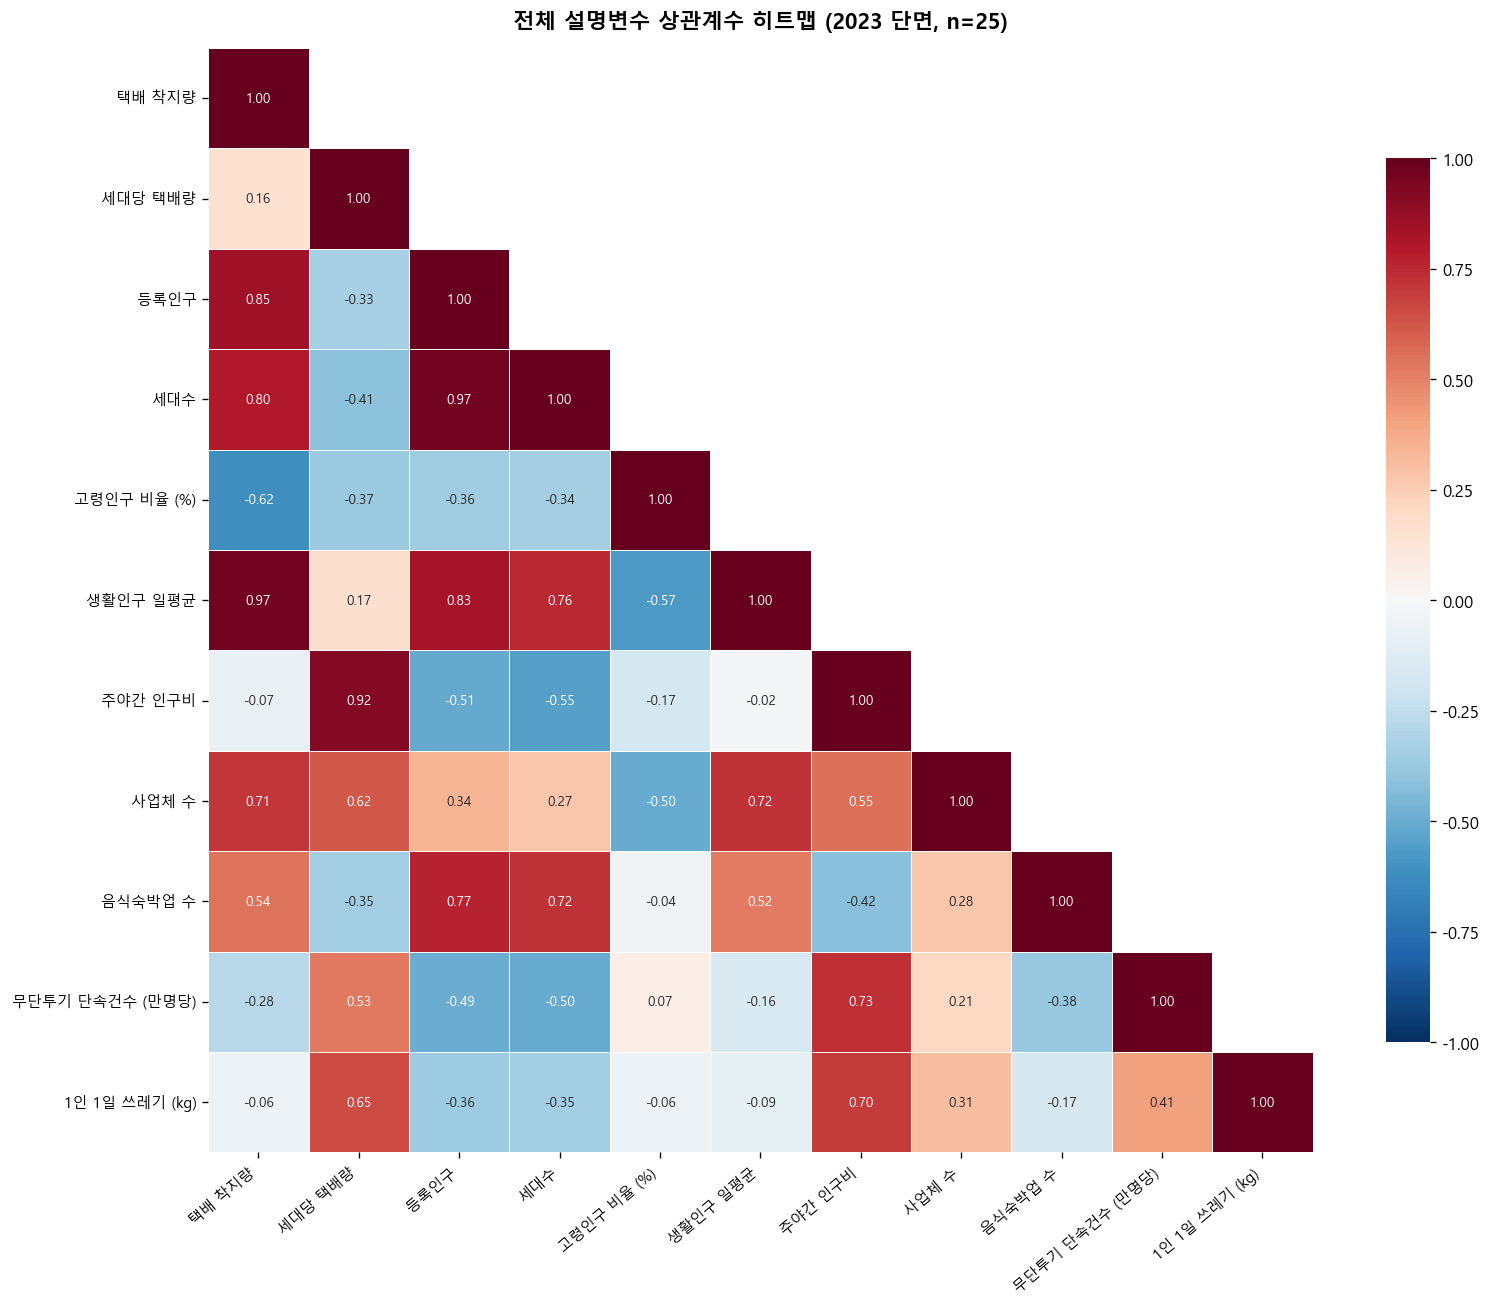

In [10]:
all_cols_23 = EXPL_2023 + EXPL_PANEL + ['waste_per_capita_kg_day']
corr23  = df23[all_cols_23].corr()
labels23 = [COL_KR.get(c, c) for c in all_cols_23]

fig, ax = plt.subplots(figsize=(14, 11))
mask23 = np.triu(np.ones_like(corr23, dtype=bool), k=1)
sns.heatmap(
    corr23, mask=mask23,
    annot=True, fmt='.2f', annot_kws={'size': 8},
    cmap='RdBu_r', vmin=-1, vmax=1, center=0,
    linewidths=0.4, linecolor='white',
    xticklabels=labels23, yticklabels=labels23,
    ax=ax, square=True, cbar_kws={'shrink': 0.8}
)
ax.set_title('전체 설명변수 상관계수 히트맵 (2023 단면, n=25)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

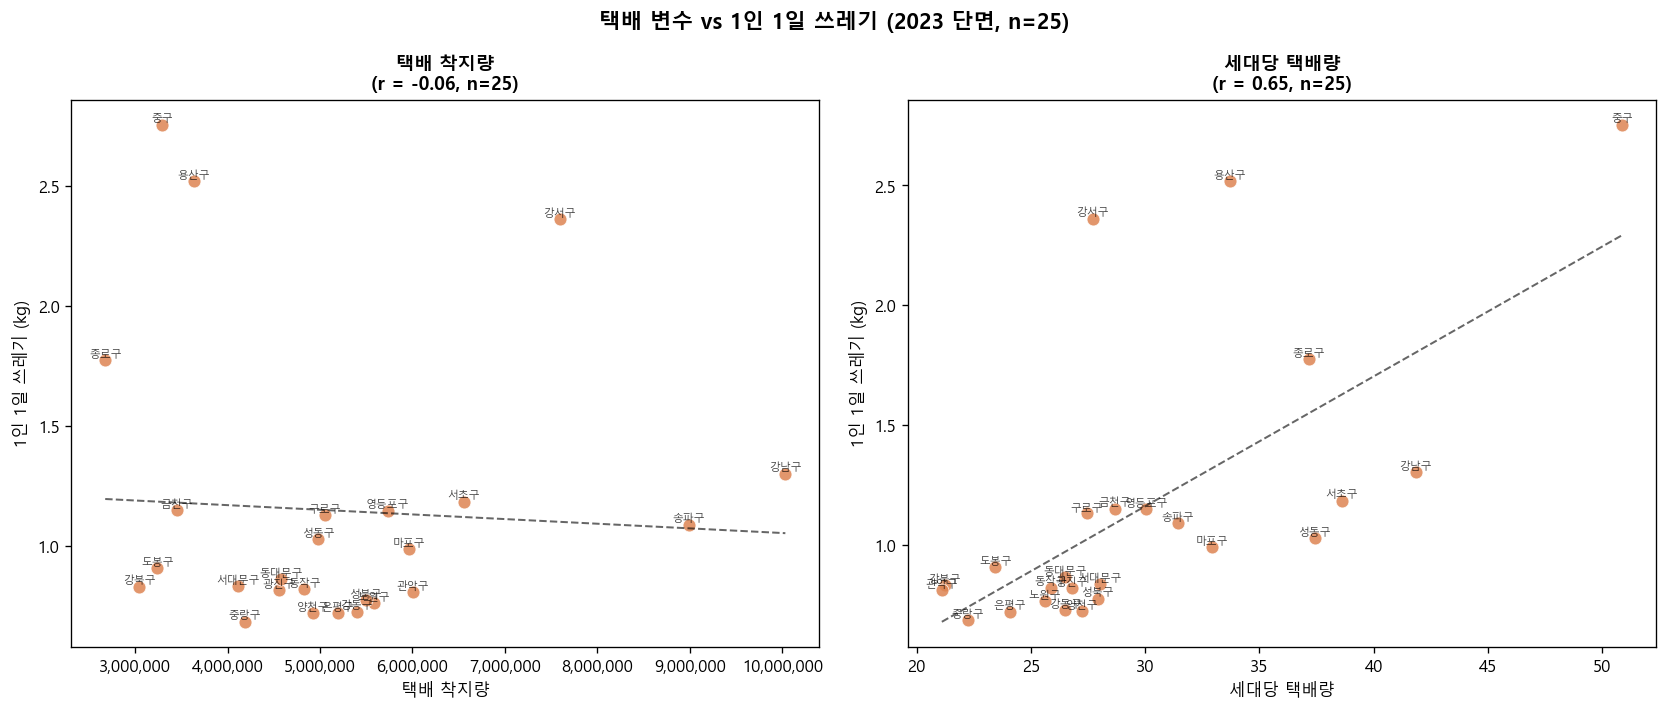

In [11]:
# parcel 산점도 (2023, n=25, 자치구명 레이블)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, col in zip(axes, EXPL_2023):
    ax.scatter(df23[col], df23['waste_per_capita_kg_day'],
               color='#DD8452', s=60, edgecolors='white', linewidths=0.5, alpha=0.85)
    for _, row in df23.iterrows():
        ax.annotate(row['gu'], (row[col], row['waste_per_capita_kg_day']),
                    fontsize=6.5, ha='center', va='bottom', alpha=0.75)
    z = np.polyfit(df23[col], df23['waste_per_capita_kg_day'], 1)
    x_line = np.linspace(df23[col].min(), df23[col].max(), 100)
    ax.plot(x_line, np.poly1d(z)(x_line), 'k--', linewidth=1.2, alpha=0.6)
    r = df23[[col, 'waste_per_capita_kg_day']].corr().iloc[0, 1]
    ax.set_title(f'{COL_KR.get(col, col)}\n(r = {r:.2f}, n=25)',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel(COL_KR.get(col, col))
    ax.set_ylabel(COL_KR['waste_per_capita_kg_day'])
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

fig.suptitle('택배 변수 vs 1인 1일 쓰레기 (2023 단면, n=25)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Pairplot (상관계수 상위 설명변수)

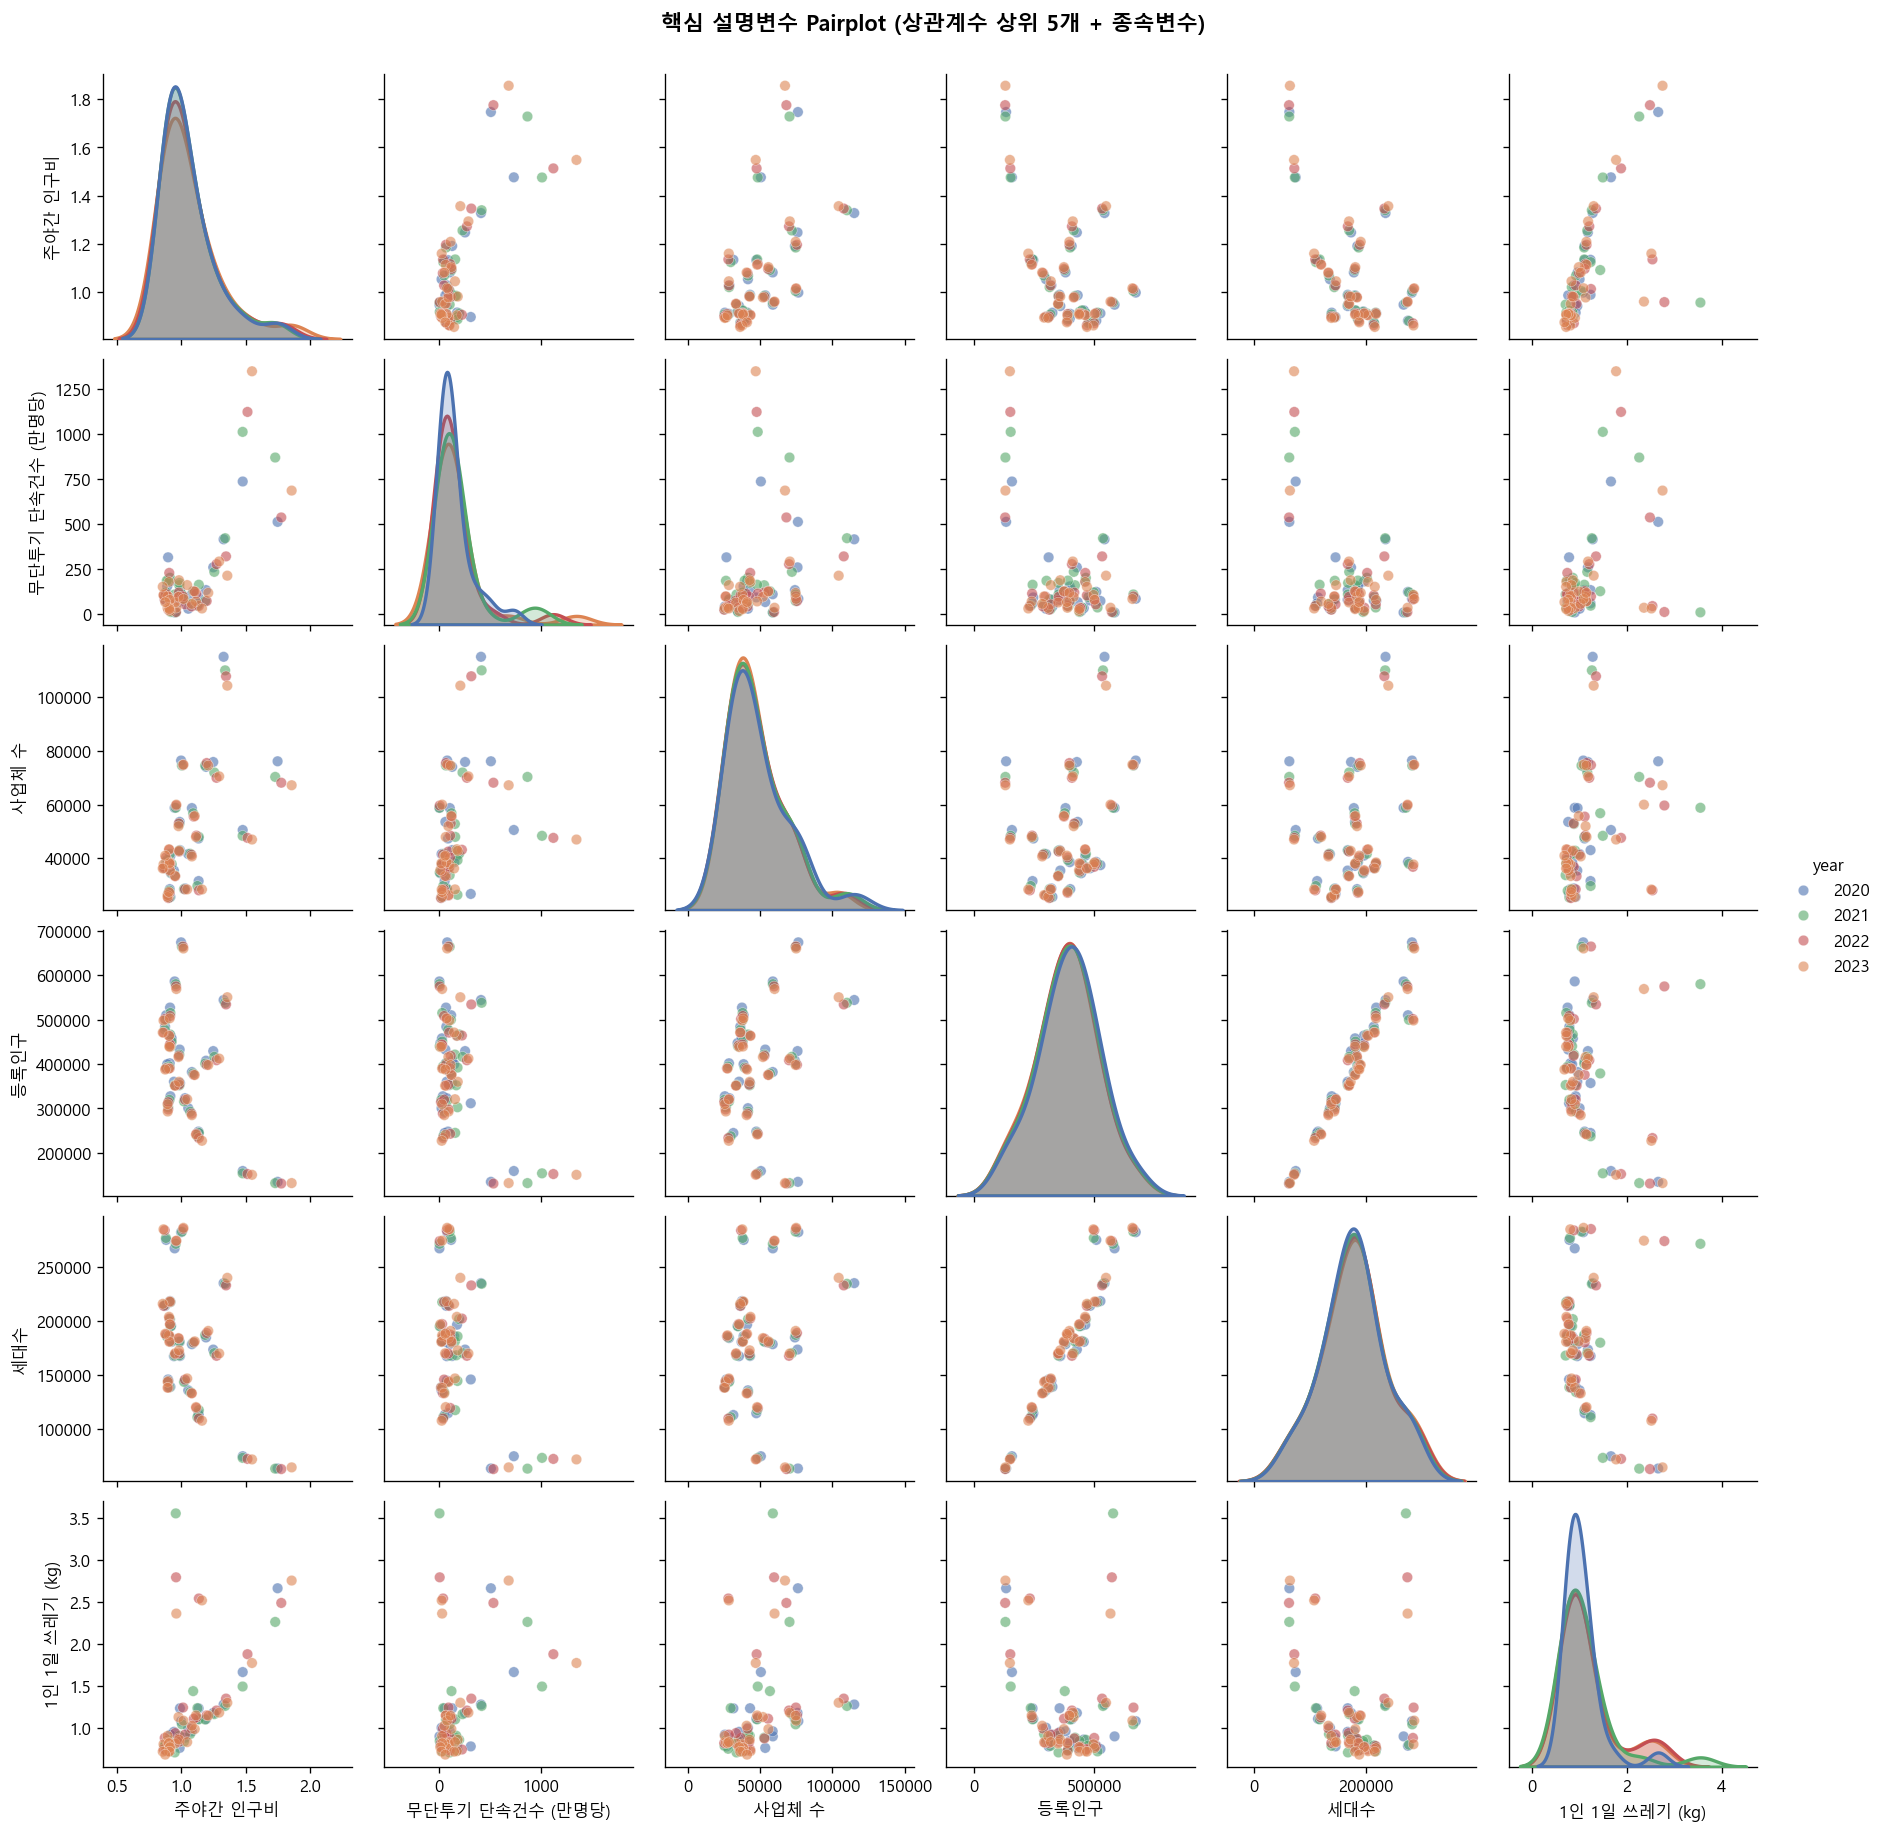

In [12]:
top_cols  = corr_target.abs().nlargest(5).index.tolist()
pair_cols = top_cols + ['waste_per_capita_kg_day']

pair_df = df[pair_cols + ['year']].copy()
pair_df['year'] = pair_df['year'].astype(str)
pair_df = pair_df.rename(columns={c: COL_KR.get(c, c) for c in pair_cols})

g = sns.pairplot(
    pair_df, hue='year',
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 40, 'edgecolor': 'white', 'linewidth': 0.3},
    diag_kws={'linewidth': 2},
    palette={str(y): c for y, c in year_colors.items()}
)
g.figure.suptitle('핵심 설명변수 Pairplot (상관계수 상위 5개 + 종속변수)',
                   y=1.02, fontsize=13, fontweight='bold')
plt.show()

---
## 8. 요약

In [13]:
print('=== [패널, n=100] waste_per_capita_kg_day 와의 상관계수 ===')
for col, val in corr_target.items():
    bar = '|' * int(abs(val) * 20)
    direction = '양(+)' if val > 0 else '음(-)'
    print(f'  {COL_KR.get(col, col):<24}  r={val:+.3f}  {direction}  {bar}')

print()
print('=== [2023 단면, n=25] 택배 변수 와의 상관계수 ===')
corr23_target = (df23[EXPL_2023 + ['waste_per_capita_kg_day']]
                 .corr()['waste_per_capita_kg_day'].drop('waste_per_capita_kg_day'))
for col, val in corr23_target.items():
    direction = '양(+)' if val > 0 else '음(-)'
    print(f'  {COL_KR.get(col, col):<24}  r={val:+.3f}  {direction}')

=== [패널, n=100] waste_per_capita_kg_day 와의 상관계수 ===
  주야간 인구비                   r=+0.638  양(+)  ||||||||||||
  무단투기 단속건수 (만명당)           r=+0.400  양(+)  ||||||||
  사업체 수                     r=+0.356  양(+)  |||||||
  등록인구                      r=-0.267  음(-)  |||||
  세대수                       r=-0.248  음(-)  ||||
  음식숙박업 수                   r=-0.045  음(-)  
  생활인구 일평균                  r=-0.044  음(-)  
  고령인구 비율 (%)               r=-0.013  음(-)  

=== [2023 단면, n=25] 택배 변수 와의 상관계수 ===
  택배 착지량                    r=-0.059  음(-)
  세대당 택배량                   r=+0.653  양(+)


---
## 9. 다중공선성 — 상관 높은 변수쌍 정리

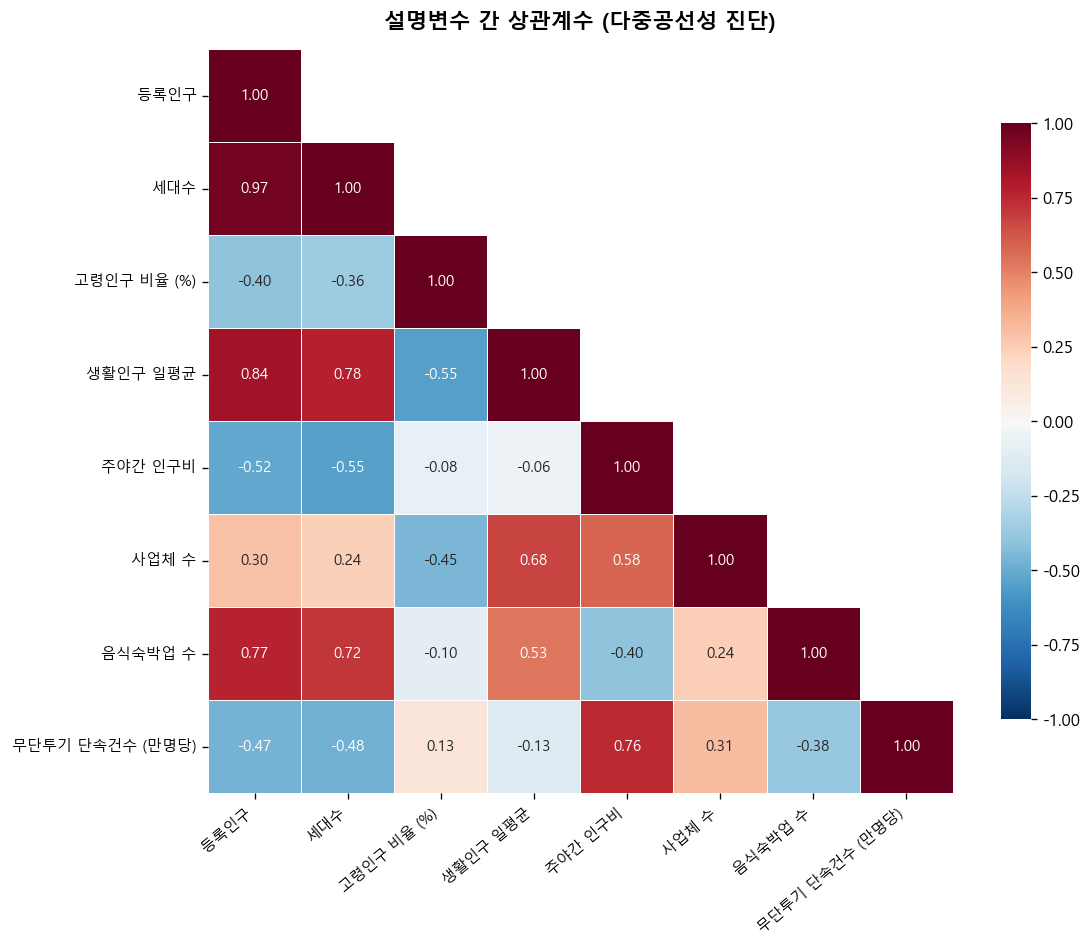

=== |r| > 0.7 다중공선성 위험 쌍 ===
  ⚠ 위험  등록인구                 ↔  세대수                   r=+0.966
  △ 주의  등록인구                 ↔  생활인구 일평균              r=+0.842
  △ 주의  등록인구                 ↔  음식숙박업 수               r=+0.766
  △ 주의  세대수                  ↔  생활인구 일평균              r=+0.779
  △ 주의  세대수                  ↔  음식숙박업 수               r=+0.719
  △ 주의  주야간 인구비              ↔  무단투기 단속건수 (만명당)       r=+0.758


In [14]:
corr_expl = df[EXPL_PANEL].corr()

# 상삼각 마스크 히트맵
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_expl, dtype=bool), k=1)
labels_e = [COL_KR.get(c, c) for c in EXPL_PANEL]
sns.heatmap(
    corr_expl, mask=mask,
    annot=True, fmt='.2f', annot_kws={'size': 9},
    cmap='RdBu_r', vmin=-1, vmax=1, center=0,
    linewidths=0.4, linecolor='white',
    xticklabels=labels_e, yticklabels=labels_e,
    ax=ax, square=True, cbar_kws={'shrink': 0.8}
)
ax.set_title('설명변수 간 상관계수 (다중공선성 진단)', fontsize=13, fontweight='bold', pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

# |r| > 0.7 쌍 출력
THRESHOLD = 0.7
print(f'=== |r| > {THRESHOLD} 다중공선성 위험 쌍 ===')
found = False
for i in range(len(EXPL_PANEL)):
    for j in range(i + 1, len(EXPL_PANEL)):
        r = corr_expl.iloc[i, j]
        if abs(r) > THRESHOLD:
            flag = '⚠ 위험' if abs(r) > 0.9 else '△ 주의'
            print(f'  {flag}  {COL_KR.get(EXPL_PANEL[i]):<20} ↔  {COL_KR.get(EXPL_PANEL[j]):<20}  r={r:+.3f}')
            found = True
if not found:
    print('  없음')

---
## 10. 모델별 설명변수 선택

| 모델 | 종속변수 | 선택 변수 | 제외 이유 |
|------|----------|-----------|-----------|
| **모델 A** | waste_total (총발생량) | living_pop_daily_avg, food_accom_biz, elderly_ratio | total_pop·households는 생활인구와 r>0.8 중복 |
| **모델 B** | waste_per_capita_kg_day (1인당) | day_night_ratio, food_accom_biz_per_10k_pop, elderly_ratio | biz_per_10k_pop은 food_accom_biz_per_10k_pop과 VIF>10 → 음식숙박업 특화 변수만 유지 |

── 모델 A: 총발생량 ──


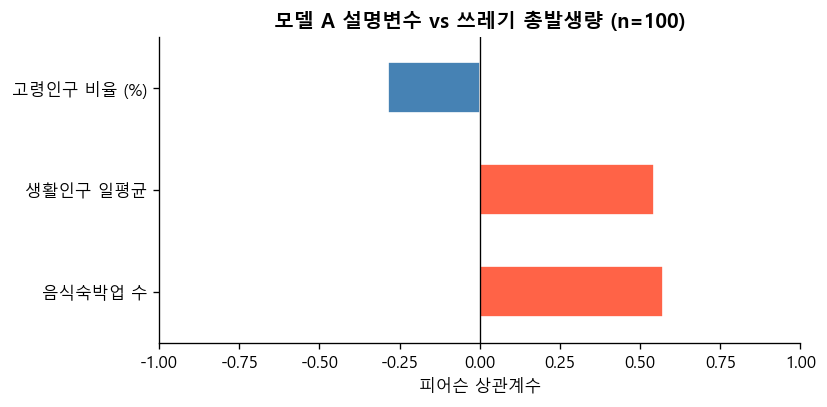

food_accom_biz          0.572
living_pop_daily_avg    0.543
elderly_ratio          -0.287

── 모델 B: 1인당 ──


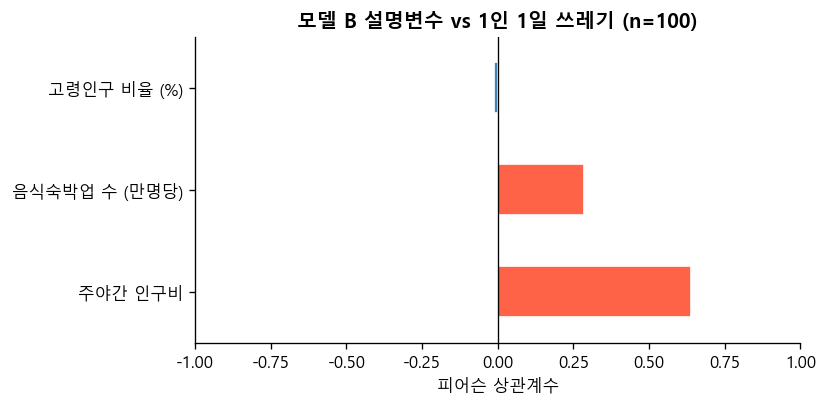

day_night_ratio               0.638
food_accom_biz_per_10k_pop    0.283
elderly_ratio                -0.013


In [15]:
# 모델 A: waste_total
MODEL_A_VARS   = ['living_pop_daily_avg', 'food_accom_biz', 'elderly_ratio']
MODEL_A_TARGET = 'waste_total'

# 모델 B: waste_per_capita_kg_day
# biz_per_10k_pop은 food_accom_biz_per_10k_pop과 VIF>10 → 제거
MODEL_B_VARS   = ['day_night_ratio', 'food_accom_biz_per_10k_pop', 'elderly_ratio']
MODEL_B_TARGET = 'waste_per_capita_kg_day'

def corr_bar(vars_, target, title, n=None):
    data = df[vars_ + [target]].dropna()
    n = n or len(data)
    corr_s = data.corr()[target].drop(target).sort_values(key=abs, ascending=False)
    colors = ['tomato' if v > 0 else 'steelblue' for v in corr_s]
    fig, ax = plt.subplots(figsize=(7, 3.5))
    corr_s.plot.barh(ax=ax, color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlim(-1, 1)
    ax.set_xlabel('피어슨 상관계수')
    ax.set_title(f'{title} (n={n})', fontsize=12, fontweight='bold')
    ax.set_yticklabels([COL_KR.get(c, c) for c in corr_s.index])
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)
    plt.tight_layout()
    plt.show()
    return corr_s

print('── 모델 A: 총발생량 ──')
corr_a = corr_bar(MODEL_A_VARS, MODEL_A_TARGET, '모델 A 설명변수 vs 쓰레기 총발생량')
print(corr_a.round(3).to_string())

print('\n── 모델 B: 1인당 ──')
corr_b = corr_bar(MODEL_B_VARS, MODEL_B_TARGET, '모델 B 설명변수 vs 1인 1일 쓰레기')
print(corr_b.round(3).to_string())

---
## 11. VIF 확인


=== 모델 A (waste_total) VIF ===
        변수명  VIF       판정
   생활인구 일평균 2.13 ✓ 양호(<5)
    음식숙박업 수 1.50 ✓ 양호(<5)
고령인구 비율 (%) 1.54 ✓ 양호(<5)

=== 모델 B (waste_per_capita_kg_day) VIF ===
          변수명  VIF       판정
      주야간 인구비 1.06 ✓ 양호(<5)
음식숙박업 수 (만명당) 1.23 ✓ 양호(<5)
  고령인구 비율 (%) 1.19 ✓ 양호(<5)


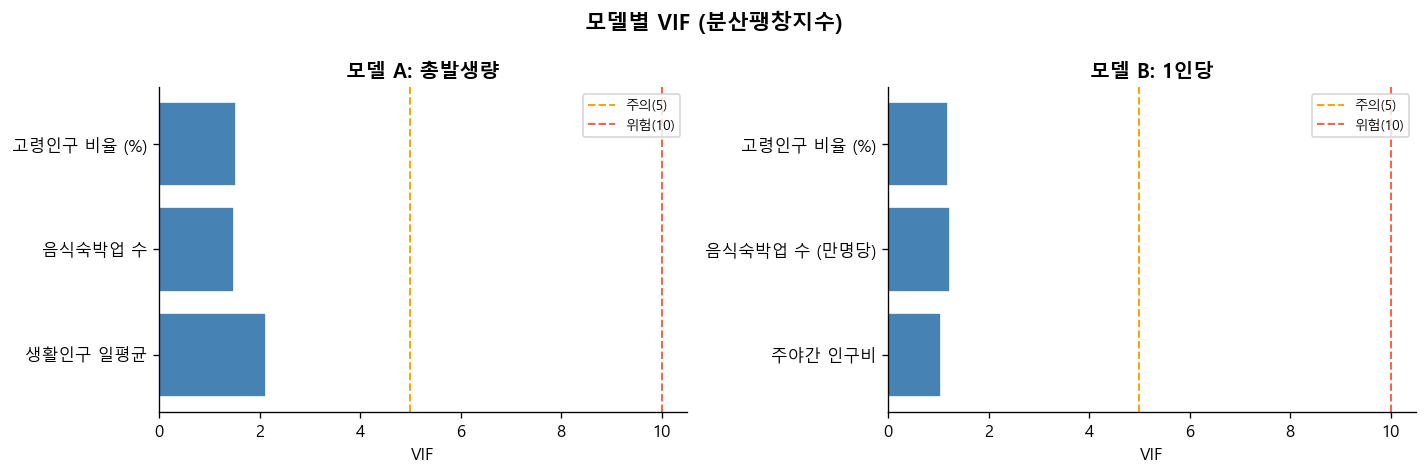

In [16]:
def calc_vif(vars_, label):
    """statsmodels 없이 numpy로 VIF 직접 계산"""
    data = df[vars_].dropna().values.astype(float)
    # 표준화 (수치 안정성)
    data = (data - data.mean(axis=0)) / data.std(axis=0)

    vif_vals = []
    for i in range(data.shape[1]):
        y = data[:, i]
        X = np.delete(data, i, axis=1)
        X = np.column_stack([np.ones(len(y)), X])
        coef, *_ = np.linalg.lstsq(X, y, rcond=None)
        y_hat = X @ coef
        ss_res = np.sum((y - y_hat) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
        vif_vals.append(1 / (1 - r2) if r2 < 1 else np.inf)

    vif_df = pd.DataFrame({
        '변수':  vars_,
        '변수명': [COL_KR.get(v, v) for v in vars_],
        'VIF':   [round(v, 2) for v in vif_vals],
    })
    vif_df['판정'] = vif_df['VIF'].apply(
        lambda v: '⚠ 위험(>10)' if v > 10 else ('△ 주의(5~10)' if v > 5 else '✓ 양호(<5)')
    )
    print(f'\n=== {label} VIF ===')
    print(vif_df[['변수명', 'VIF', '판정']].to_string(index=False))
    return vif_df

vif_a = calc_vif(MODEL_A_VARS, '모델 A (waste_total)')
vif_b = calc_vif(MODEL_B_VARS, '모델 B (waste_per_capita_kg_day)')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, vif_df, title in zip(axes,
                              [vif_a, vif_b],
                              ['모델 A: 총발생량', '모델 B: 1인당']):
    colors = ['tomato' if v > 10 else ('orange' if v > 5 else 'steelblue')
              for v in vif_df['VIF']]
    ax.barh(vif_df['변수명'], vif_df['VIF'], color=colors, edgecolor='white')
    ax.axvline(5,  color='orange', linewidth=1.2, linestyle='--', label='주의(5)')
    ax.axvline(10, color='tomato', linewidth=1.2, linestyle='--', label='위험(10)')
    ax.set_xlabel('VIF')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)

fig.suptitle('모델별 VIF (분산팽창지수)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 12. 대시보드용 요약 메시지

In [17]:
lines = []

lines.append('=' * 60)
lines.append(' 서울시 자치구별 쓰레기 발생량 분석 — EDA 요약')
lines.append('=' * 60)

# ── 다중공선성 위험 쌍 ──
lines.append('\n[다중공선성] 제거된 변수쌍 (|r| > 0.7)')
for i in range(len(EXPL_PANEL)):
    for j in range(i + 1, len(EXPL_PANEL)):
        r = corr_expl.iloc[i, j]
        if abs(r) > 0.7:
            lines.append(f'  • {COL_KR.get(EXPL_PANEL[i])} ↔ {COL_KR.get(EXPL_PANEL[j])}  (r={r:+.2f})')

# ── 모델 A ──
lines.append('\n[모델 A] 종속변수: 쓰레기 총발생량 (waste_total)')
lines.append(f'  채택 변수: {", ".join(COL_KR.get(v, v) for v in MODEL_A_VARS)}')
for c, v in corr_a.items():
    lines.append(f'    - {COL_KR.get(c, c):<22}  r={v:+.3f}')
lines.append('  VIF:')
for _, row in vif_a.iterrows():
    lines.append(f'    - {row["변수명"]:<22}  VIF={row["VIF"]:.2f}  {row["판정"]}')

# ── 모델 B ──
lines.append('\n[모델 B] 종속변수: 1인 1일 쓰레기 배출량 (waste_per_capita_kg_day)')
lines.append(f'  채택 변수: {", ".join(COL_KR.get(v, v) for v in MODEL_B_VARS)}')
for c, v in corr_b.items():
    lines.append(f'    - {COL_KR.get(c, c):<22}  r={v:+.3f}')
lines.append('  VIF:')
for _, row in vif_b.iterrows():
    lines.append(f'    - {row["변수명"]:<22}  VIF={row["VIF"]:.2f}  {row["판정"]}')

lines.append('\n[데이터] 서울 25구 × 2020~2023 패널 (n=100)')
lines.append('=' * 60)

msg = '\n'.join(lines)
print(msg)

 서울시 자치구별 쓰레기 발생량 분석 — EDA 요약

[다중공선성] 제거된 변수쌍 (|r| > 0.7)
  • 등록인구 ↔ 세대수  (r=+0.97)
  • 등록인구 ↔ 생활인구 일평균  (r=+0.84)
  • 등록인구 ↔ 음식숙박업 수  (r=+0.77)
  • 세대수 ↔ 생활인구 일평균  (r=+0.78)
  • 세대수 ↔ 음식숙박업 수  (r=+0.72)
  • 주야간 인구비 ↔ 무단투기 단속건수 (만명당)  (r=+0.76)

[모델 A] 종속변수: 쓰레기 총발생량 (waste_total)
  채택 변수: 생활인구 일평균, 음식숙박업 수, 고령인구 비율 (%)
    - 음식숙박업 수                 r=+0.572
    - 생활인구 일평균                r=+0.543
    - 고령인구 비율 (%)             r=-0.287
  VIF:
    - 생활인구 일평균                VIF=2.13  ✓ 양호(<5)
    - 음식숙박업 수                 VIF=1.50  ✓ 양호(<5)
    - 고령인구 비율 (%)             VIF=1.54  ✓ 양호(<5)

[모델 B] 종속변수: 1인 1일 쓰레기 배출량 (waste_per_capita_kg_day)
  채택 변수: 주야간 인구비, 음식숙박업 수 (만명당), 고령인구 비율 (%)
    - 주야간 인구비                 r=+0.638
    - 음식숙박업 수 (만명당)           r=+0.283
    - 고령인구 비율 (%)             r=-0.013
  VIF:
    - 주야간 인구비                 VIF=1.06  ✓ 양호(<5)
    - 음식숙박업 수 (만명당)           VIF=1.23  ✓ 양호(<5)
    - 고령인구 비율 (%)             VIF=1.19  ✓ 양호(<5)

[데이터] 서울 25구 × 2020~2023 패널 (n=100)